# **Ejemplo 1:**

Ejemplo clásico de aplicación de PINN (Physics-Informed Neural Networks) sobre la ecuación de Poisson con una función de dominio cuadrado de grandes oscilaciones.

Configuración inicial del entorno y de las librerías:

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

import torch
import torch.nn as nn

# Reproducibilidad (los resultados del PINN varian algo entre corridas)
np.random.seed(0)
torch.manual_seed(0)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| dispositivo:", device)


PyTorch 2.11.0+cpu | dispositivo: cpu


In [ ]:
# Datos del problema (versiones NumPy, para el metodo clasico y las graficas)
#def f_np(x):        return (np.pi**2) * np.sin(np.pi * x)   # termino fuente
        # solucion exacta

def rel_L2(u_num, u_ref):
    return np.sqrt(np.mean((u_num - u_ref)**2)) / np.sqrt(np.mean(u_ref**2))


## **1. Arquitectura de las Red Neuronal:**

Declaramos la red neuronal que dará la solución de la PDE:

In [7]:
class MLP(nn.Module):
    """Perceptron multicapa estándar con activacion tanh."""
    def __init__(self, layers=(2, 64, 64, 64, 1)): #Recibe al inicio un punto bidimensional
        super().__init__()
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(nn.Tanh())
        self.net = nn.Sequential(*mods)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

## **2. Declaración del PINN para ecuación de Poisson en 2D:**

Se plantea una ecuación de Poisson (ecuación diferencial parcial elíptica), de la forma:  $$ −∇^{2}u(x) = f(x),\quad x ∈ Ω$$

En este caso, se tiene definida la función $f$ como:.

$$f(x, y) = 50 \sin (20\pi x) \sin(20\pi y)$$

A partir de ello, planteamos la solución a partir del PINN de la siguiente manera:

Entrenando PINN Estándar:
  paso     0  L=6.363e+02  Lf=6.355e+02
  paso  1000  L=4.548e+02  Lf=4.547e+02
  paso  2000  L=3.475e+02  Lf=3.474e+02
  paso  3000  L=2.958e+02  Lf=2.957e+02
  paso  4000  L=2.691e+02  Lf=2.690e+02
  paso  5000  L=2.371e+02  Lf=2.369e+02


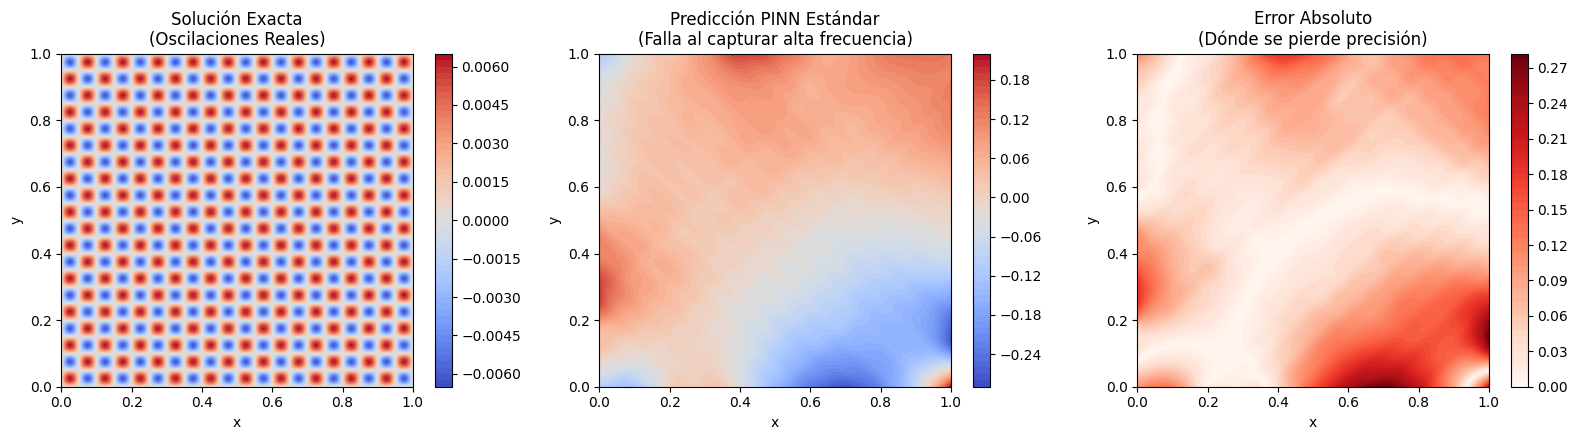

In [9]:
def laplacian(net, xy):
  """Calcula el Laplaciano en 2D."""
  u = net(xy)
  grad_u = torch.autograd.grad(u, xy, grad_outputs=torch.ones_like(u), create_graph=True)[0]
  u_x = grad_u[:, 0:1]
  u_y = grad_u[:, 1:2]

  u_xx = torch.autograd.grad(u_x, xy, grad_outputs=torch.ones_like(u_x), create_graph=True)[0][:, 0:1]
  u_yy = torch.autograd.grad(u_y, xy, grad_outputs=torch.ones_like(u_y), create_graph=True)[0][:, 1:2]
  return u, u_xx + u_yy

#Función f de la ecuación de Poisson:
def f_torch(xy):
  x = xy[:, 0:1]
  y = xy[:, 1:2]
  return 50 * torch.sin(20 * np.pi * x) * torch.sin(20 * np.pi * y)

#Solución exacta definida con ayuda de la IA:
def u_exacta_np(x, y):
  """Solución analítica exacta para comparar el error."""
  amplitud = 50.0 / (2.0 * (20.0 * np.pi)**2)
  return amplitud * np.sin(20 * np.pi * x) * np.sin(20 * np.pi * y)

# --- Preparar puntos ---
torch.manual_seed(0)
net = MLP().to(device)

 # Usamos más puntos debido a la alta frecuencia de f
N_f = 4096

#Generando puntos aleatorios esparcidos por toda el área:
xy_f = torch.rand(N_f, 2, device=device).requires_grad_(True)
N_b = 400

#Definición de condiciones de frontera:
puntos_borde = torch.rand(N_b, 1, device=device)
ceros = torch.zeros_like(puntos_borde)
unos = torch.ones_like(puntos_borde)

#Aplicando condiciones de frontera (es una función en 3D):
borde_inf = torch.cat((puntos_borde, ceros), dim=1)
borde_sup = torch.cat((puntos_borde, unos), dim=1)
borde_izq = torch.cat((ceros, puntos_borde), dim=1)
borde_der = torch.cat((unos, puntos_borde), dim=1)

xy_b = torch.cat([borde_inf, borde_sup, borde_izq, borde_der], dim=0)
lam_b = 10.0  #Valor que multiplica la pérdida de frontera

opt = torch.optim.Adam(net.parameters(), lr=1e-3)
n_steps = 5000 #Cantidad de pasos

print("Entrenando PINN Estándar:")
t0 = time.perf_counter()

for it in range(n_steps + 1):
  opt.zero_grad()

  u, laplace_u = laplacian(net, xy_f)
  res     = -laplace_u - f_torch(xy_f)
  loss_f  = (res**2).mean()
  loss_b  = (net(xy_b)**2).mean()
  loss    = loss_f + lam_b * loss_b

  loss.backward()
  opt.step()

  if it % 1000 == 0:
    print(f"  paso {it:5d}  L={loss.item():.3e}  Lf={loss_f.item():.3e}")

# Evaluar y graficar para mostrar pérdida de precisión:
x_vals = np.linspace(0, 1, 200)
y_vals = np.linspace(0, 1, 200)
X, Y = np.meshgrid(x_vals, y_vals)

xy_plot = np.hstack((X.flatten()[:, None], Y.flatten()[:, None]))
xy_t = torch.tensor(xy_plot, dtype=torch.float32, device=device)

with torch.no_grad():
    U_pred = net(xy_t).cpu().numpy().reshape(X.shape)

U_exact = u_exacta_np(X, Y)
Error_Absoluto = np.abs(U_exact - U_pred)

# Graficar comparativa
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

#Solución Exacta (Heatmap)
c0 = axs[0].contourf(X, Y, U_exact, levels=50, cmap='coolwarm')
axs[0].set_title('Solución Exacta\n(Oscilaciones Reales)')
fig.colorbar(c0, ax=axs[0])

#Predicción de la PINN Estándar (Heatmap)
c1 = axs[1].contourf(X, Y, U_pred, levels=50, cmap='coolwarm')
axs[1].set_title('Predicción PINN Estándar\n(Falla al capturar alta frecuencia)')
fig.colorbar(c1, ax=axs[1])

# Error Absoluto (Heatmap)
c2 = axs[2].contourf(X, Y, Error_Absoluto, levels=50, cmap='Reds')
axs[2].set_title('Error Absoluto\n(Dónde se pierde precisión)')
fig.colorbar(c2, ax=axs[2])

for ax in axs:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()